In [18]:
# Configuración inicial del entorno
import sys
import os
from pathlib import Path

print("🔄 Configurando entorno...")

# Obtener el directorio raíz del proyecto
notebook_dir = Path().resolve()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    # Buscar el directorio con pyproject.toml
    project_root = notebook_dir
    while project_root != project_root.parent:
        if (project_root / "pyproject.toml").exists():
            break
        project_root = project_root.parent

print(f"📁 Directorio raíz: {project_root}")

# Cambiar al directorio raíz
os.chdir(project_root)
print(f"✓ Directorio de trabajo: {os.getcwd()}")

# Agregar al path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Verificar pyproject.toml
if (project_root / "pyproject.toml").exists():
    print("✓ pyproject.toml encontrado")
else:
    raise FileNotFoundError(f"pyproject.toml no encontrado en {project_root}")

print("✅ Configuración completada\n")


🔄 Configurando entorno...
📁 Directorio raíz: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ Directorio de trabajo: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ pyproject.toml encontrado
✅ Configuración completada



# 📈 Análisis Final del Proyecto ML Clash Royale

Este notebook integra todos los resultados del proyecto:
- Modelos supervisados (Clasificación y Regresión)
- Modelos no supervisados (Clustering, Reducción de Dimensionalidad, Detección de Anomalías, Reglas de Asociación)
- Conclusiones y recomendaciones finales


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas exitosamente")


✅ Librerías importadas exitosamente


## 1. Resumen Ejecutivo

### 1.1. Objetivos del Proyecto
- Predecir resultados de batallas (clasificación)
- Predecir cambios de trofeos (regresión)
- Identificar patrones en los datos (clustering)
- Reducir dimensionalidad para visualización
- Detectar anomalías en batallas
- Encontrar reglas de asociación entre cartas


## 2. Resultados de Modelos Supervisados

### 2.1. Clasificación


[11/28/25 17:16:13] WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 17:16:14] INFO     Loading data from classification_comparison (JSONDataset)...      data_catalog.py:1048

✅ Métricas de clasificación cargadas desde catálogo

📊 Modelos de Clasificación:

LOGISTIC REGRESSION:
  - Accuracy: 0.4726
  - ROC-AUC: 0.4652
  - F1-Score: 0.4796

RANDOM FOREST:
  - Accuracy: 0.4481
  - ROC-AUC: 0.4356
  - F1-Score: 0.4478

XGBOOST:
  - Accuracy: 0.5227
  - ROC-AUC: 0.5372
  - F1-Score: 0.5278

SVC:
  - Accuracy: 0.4716
  - ROC-AUC: 0.4639
  - F1-Score: 0.4788

LIGHTGBM:
  - Accuracy: 0.5217
  - ROC-AUC: 0.5359
  - F1-Score: 0.5206


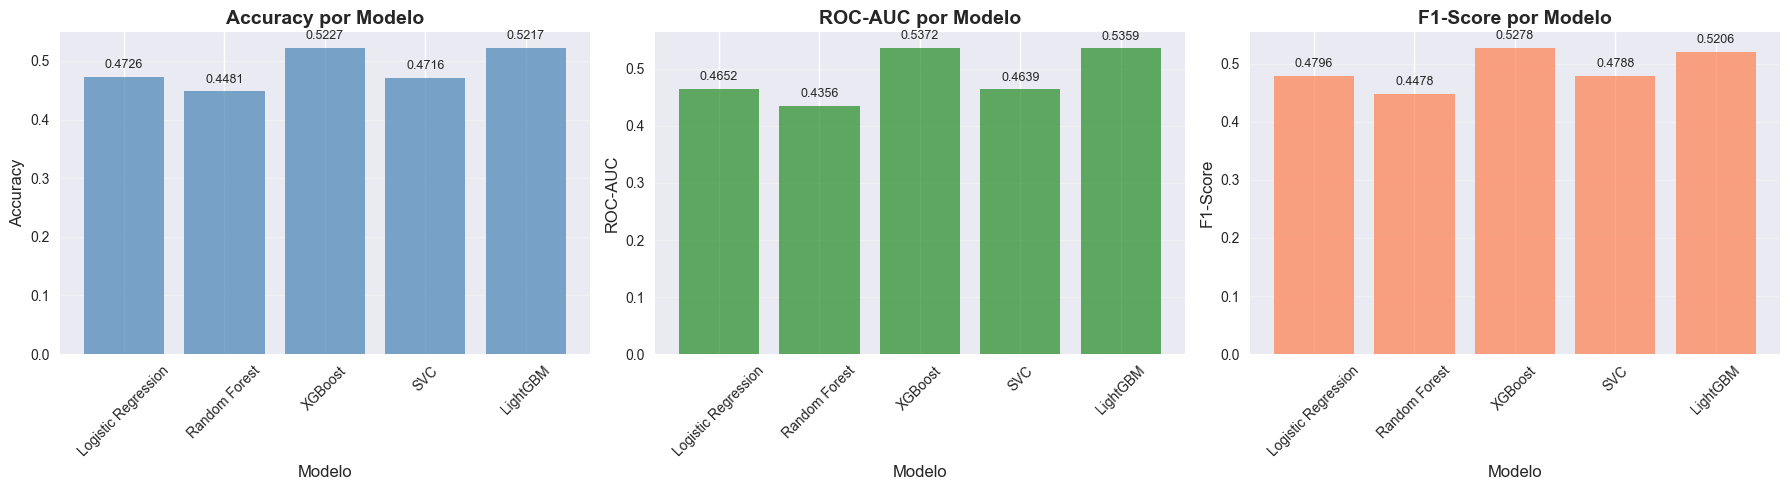

In [20]:
# Cargar comparación de clasificación
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        classification_comparison = catalog.load("classification_comparison")
        print("✅ Métricas de clasificación cargadas desde catálogo")
    except Exception:
        # Fallback a archivo
        classification_path = project_root / "data" / "08_reporting" / "classification_comparison.json"
        if classification_path.exists():
            with open(classification_path, 'r') as f:
                classification_comparison = json.load(f)
            print("✅ Métricas de clasificación cargadas desde archivo")
        else:
            raise FileNotFoundError(f"Archivo no encontrado: {classification_path}")
    
    print("\n📊 Modelos de Clasificación:")
    print("=" * 50)
    
    # Verificar estructura de datos
    if 'models' in classification_comparison:
        # Estructura: {'models': {'Logistic Regression': {'metrics': {...}}, ...}}
        models_dict = classification_comparison['models']
        for model, model_data in models_dict.items():
            if isinstance(model_data, dict) and 'metrics' in model_data:
                metrics = model_data['metrics']
            else:
                metrics = model_data
    else:
        # Estructura directa: {'logistic': {...}, 'random_forest': {...}, ...}
        models_dict = {k: v for k, v in classification_comparison.items() if k != 'best_models'}
        metrics = None
    
    # Preparar datos para gráficos
    models_list = []
    accuracy_list = []
    roc_auc_list = []
    f1_list = []
    
    # Si tenemos models_dict con estructura anidada
    if 'models' in classification_comparison:
        for model, model_data in models_dict.items():
            if isinstance(model_data, dict):
                if 'metrics' in model_data:
                    metrics = model_data['metrics']
                else:
                    metrics = model_data
                
                print(f"\n{model.upper().replace('_', ' ')}:")
                # Manejar valores numéricos y strings
                accuracy = metrics.get('accuracy', 'N/A')
                roc_auc = metrics.get('roc_auc', 'N/A')
                f1 = metrics.get('f1', 'N/A')
                
                if isinstance(accuracy, (int, float)):
                    print(f"  - Accuracy: {accuracy:.4f}")
                    models_list.append(model)
                    accuracy_list.append(accuracy)
                else:
                    print(f"  - Accuracy: {accuracy}")
                
                if isinstance(roc_auc, (int, float)):
                    print(f"  - ROC-AUC: {roc_auc:.4f}")
                    roc_auc_list.append(roc_auc)
                else:
                    print(f"  - ROC-AUC: {roc_auc}")
                
                if isinstance(f1, (int, float)):
                    print(f"  - F1-Score: {f1:.4f}")
                    f1_list.append(f1)
                else:
                    print(f"  - F1-Score: {f1}")
    else:
        # Estructura directa
        for model, metrics in models_dict.items():
            if isinstance(metrics, dict):
                print(f"\n{model.upper().replace('_', ' ')}:")
                accuracy = metrics.get('accuracy', 'N/A')
                roc_auc = metrics.get('roc_auc', 'N/A')
                f1 = metrics.get('f1', 'N/A')
                
                if isinstance(accuracy, (int, float)):
                    print(f"  - Accuracy: {accuracy:.4f}")
                    models_list.append(model)
                    accuracy_list.append(accuracy)
                else:
                    print(f"  - Accuracy: {accuracy}")
                
                if isinstance(roc_auc, (int, float)):
                    print(f"  - ROC-AUC: {roc_auc:.4f}")
                    roc_auc_list.append(roc_auc)
                else:
                    print(f"  - ROC-AUC: {roc_auc}")
                
                if isinstance(f1, (int, float)):
                    print(f"  - F1-Score: {f1:.4f}")
                    f1_list.append(f1)
                else:
                    print(f"  - F1-Score: {f1}")
    
    # Crear gráficos si hay datos
    if models_list and accuracy_list:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Gráfico de Accuracy
        axes[0].bar(models_list, accuracy_list, color='steelblue', alpha=0.7)
        axes[0].set_title('Accuracy por Modelo', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Modelo', fontsize=12)
        axes[0].set_ylabel('Accuracy', fontsize=12)
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(accuracy_list):
            axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        
        # Gráfico de ROC-AUC
        if roc_auc_list:
            axes[1].bar(models_list, roc_auc_list, color='forestgreen', alpha=0.7)
            axes[1].set_title('ROC-AUC por Modelo', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Modelo', fontsize=12)
            axes[1].set_ylabel('ROC-AUC', fontsize=12)
            axes[1].tick_params(axis='x', rotation=45)
            axes[1].grid(axis='y', alpha=0.3)
            for i, v in enumerate(roc_auc_list):
                axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        
        # Gráfico de F1-Score
        if f1_list:
            axes[2].bar(models_list, f1_list, color='coral', alpha=0.7)
            axes[2].set_title('F1-Score por Modelo', fontsize=14, fontweight='bold')
            axes[2].set_xlabel('Modelo', fontsize=12)
            axes[2].set_ylabel('F1-Score', fontsize=12)
            axes[2].tick_params(axis='x', rotation=45)
            axes[2].grid(axis='y', alpha=0.3)
            for i, v in enumerate(f1_list):
                axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    classification_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=classification")
    classification_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    classification_comparison = None


### 2.2. Regresión


[11/28/25 17:16:15] INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

                    INFO     Loading data from regression_comparison (JSONDataset)...          data_catalog.py:1048

✅ Métricas de regresión cargadas desde catálogo

📊 Modelos de Regresión:

LINEAR REGRESSION:
  - MAE: 29.5399
  - RMSE: 29.6247
  - R²: -0.0133

RIDGE:
  - MAE: 29.5384
  - RMSE: 29.6228
  - R²: -0.0131

RANDOM FOREST:
  - MAE: 29.5075
  - RMSE: 29.5936
  - R²: -0.0111

XGBOOST:
  - MAE: 29.2482
  - RMSE: 29.3875
  - R²: 0.0029

SVR:
  - MAE: 30.3480
  - RMSE: 32.9072
  - R²: -0.2502

LIGHTGBM:
  - MAE: 29.0052
  - RMSE: 29.3237
  - R²: 0.0072


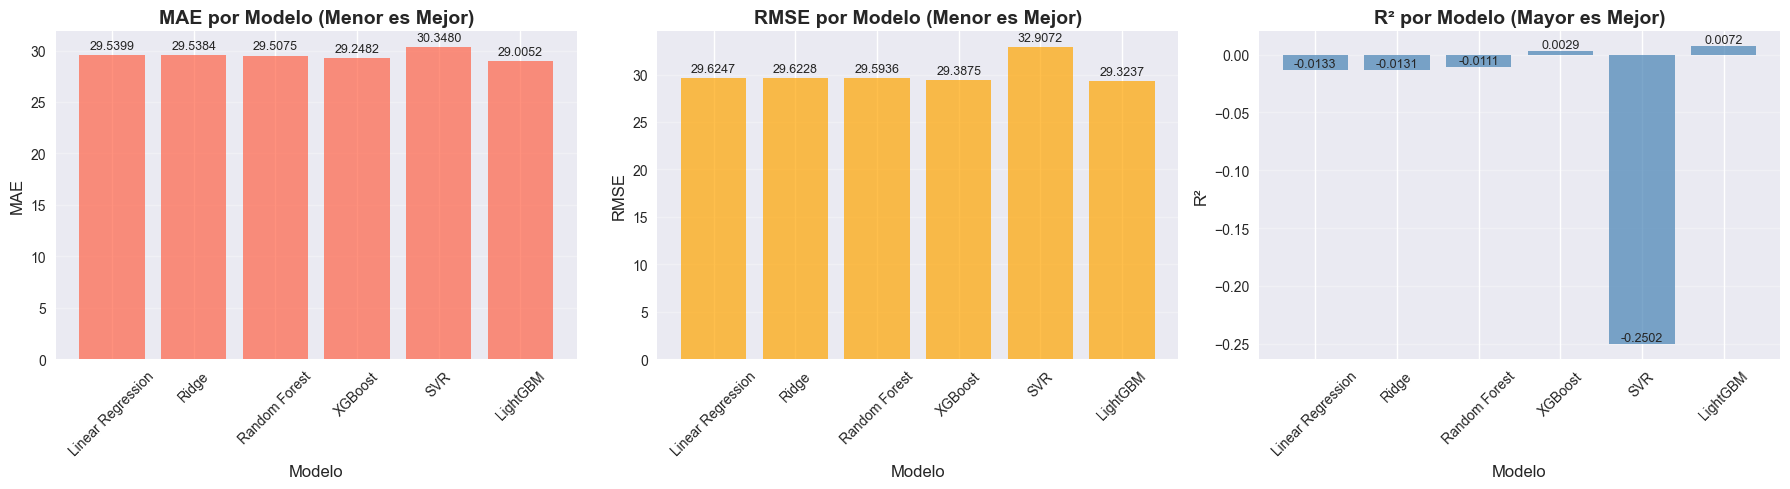

In [21]:
# Cargar comparación de regresión
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        regression_comparison = catalog.load("regression_comparison")
        print("✅ Métricas de regresión cargadas desde catálogo")
    except Exception:
        # Fallback a archivo
        regression_path = project_root / "data" / "08_reporting" / "regression_comparison.json"
        if regression_path.exists():
            with open(regression_path, 'r') as f:
                regression_comparison = json.load(f)
            print("✅ Métricas de regresión cargadas desde archivo")
        else:
            raise FileNotFoundError(f"Archivo no encontrado: {regression_path}")
    
    print("\n📊 Modelos de Regresión:")
    print("=" * 50)
    
    # Verificar estructura de datos
    if 'models' in regression_comparison:
        # Estructura: {'models': {'Linear Regression': {'metrics': {...}}, ...}}
        models_dict = regression_comparison['models']
    else:
        # Estructura directa: {'linear': {...}, 'random_forest': {...}, ...}
        models_dict = {k: v for k, v in regression_comparison.items() if k != 'best_models'}
    
    # Preparar datos para gráficos
    models_list = []
    mae_list = []
    rmse_list = []
    r2_list = []
    
    # Si tenemos models_dict con estructura anidada
    if 'models' in regression_comparison:
        for model, model_data in models_dict.items():
            if isinstance(model_data, dict):
                if 'metrics' in model_data:
                    metrics = model_data['metrics']
                else:
                    metrics = model_data
                
                print(f"\n{model.upper().replace('_', ' ')}:")
                # Manejar valores numéricos y strings
                mae = metrics.get('mae', 'N/A')
                rmse = metrics.get('rmse', 'N/A')
                r2 = metrics.get('r2', 'N/A')
                
                if isinstance(mae, (int, float)):
                    print(f"  - MAE: {mae:.4f}")
                    models_list.append(model)
                    mae_list.append(mae)
                else:
                    print(f"  - MAE: {mae}")
                
                if isinstance(rmse, (int, float)):
                    print(f"  - RMSE: {rmse:.4f}")
                    rmse_list.append(rmse)
                else:
                    print(f"  - RMSE: {rmse}")
                
                if isinstance(r2, (int, float)):
                    print(f"  - R²: {r2:.4f}")
                    r2_list.append(r2)
                else:
                    print(f"  - R²: {r2}")
    else:
        # Estructura directa
        for model, metrics in models_dict.items():
            if isinstance(metrics, dict):
                print(f"\n{model.upper().replace('_', ' ')}:")
                mae = metrics.get('mae', 'N/A')
                rmse = metrics.get('rmse', 'N/A')
                r2 = metrics.get('r2', 'N/A')
                
                if isinstance(mae, (int, float)):
                    print(f"  - MAE: {mae:.4f}")
                    models_list.append(model)
                    mae_list.append(mae)
                else:
                    print(f"  - MAE: {mae}")
                
                if isinstance(rmse, (int, float)):
                    print(f"  - RMSE: {rmse:.4f}")
                    rmse_list.append(rmse)
                else:
                    print(f"  - RMSE: {rmse}")
                
                if isinstance(r2, (int, float)):
                    print(f"  - R²: {r2:.4f}")
                    r2_list.append(r2)
                else:
                    print(f"  - R²: {r2}")
    
    # Crear gráficos si hay datos
    if models_list and mae_list:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Gráfico de MAE (menor es mejor)
        axes[0].bar(models_list, mae_list, color='tomato', alpha=0.7)
        axes[0].set_title('MAE por Modelo (Menor es Mejor)', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Modelo', fontsize=12)
        axes[0].set_ylabel('MAE', fontsize=12)
        axes[0].tick_params(axis='x', rotation=45)
        axes[0].grid(axis='y', alpha=0.3)
        for i, v in enumerate(mae_list):
            axes[0].text(i, v + max(mae_list) * 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        
        # Gráfico de RMSE (menor es mejor)
        if rmse_list:
            axes[1].bar(models_list, rmse_list, color='orange', alpha=0.7)
            axes[1].set_title('RMSE por Modelo (Menor es Mejor)', fontsize=14, fontweight='bold')
            axes[1].set_xlabel('Modelo', fontsize=12)
            axes[1].set_ylabel('RMSE', fontsize=12)
            axes[1].tick_params(axis='x', rotation=45)
            axes[1].grid(axis='y', alpha=0.3)
            for i, v in enumerate(rmse_list):
                axes[1].text(i, v + max(rmse_list) * 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        
        # Gráfico de R² (mayor es mejor)
        if r2_list:
            axes[2].bar(models_list, r2_list, color='steelblue', alpha=0.7)
            axes[2].set_title('R² por Modelo (Mayor es Mejor)', fontsize=14, fontweight='bold')
            axes[2].set_xlabel('Modelo', fontsize=12)
            axes[2].set_ylabel('R²', fontsize=12)
            axes[2].tick_params(axis='x', rotation=45)
            axes[2].grid(axis='y', alpha=0.3)
            for i, v in enumerate(r2_list):
                axes[2].text(i, v + max(r2_list) * 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
        
        plt.tight_layout()
        plt.show()
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    regression_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=regression")
    regression_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    regression_comparison = None


## 3. Resultados de Modelos No Supervisados

### 3.1. Clustering


### 3.2. Detección de Anomalías


In [22]:
# Cargar comparación de detección de anomalías
try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde archivo primero
    anomaly_path = project_root / "data" / "08_reporting" / "anomaly_detection_comparison.json"
    
    if anomaly_path.exists():
        with open(anomaly_path, 'r', encoding='utf-8') as f:
            anomaly_comparison = json.load(f)
        print("✅ Resultados de detección de anomalías cargados desde archivo")
    else:
        # Intentar cargar desde Kedro
        try:
            from kedro.framework.session import KedroSession
            from kedro.framework.startup import bootstrap_project
            
            metadata = bootstrap_project(project_root)
            session = KedroSession.create(project_path=project_root)
            context = session.load_context()
            catalog = context.catalog
            
            anomaly_comparison = catalog.load("anomaly_detection_comparison")
            print("✅ Resultados de detección de anomalías cargados desde catálogo")
        except Exception:
            raise FileNotFoundError(f"Archivo no encontrado: {anomaly_path}")
    
    print("\n📊 Algoritmos de Detección de Anomalías:")
    print("=" * 50)
    
    available_algorithms = []
    for algo_name, algo_data in anomaly_comparison.items():
        if algo_name not in ['summary', 'best_model'] and isinstance(algo_data, dict):
            if algo_data.get('available', True):
                available_algorithms.append(algo_name)
                print(f"\n{algo_name.upper().replace('_', ' ')}:")
                print(f"  - Anomalías detectadas: {algo_data.get('n_anomalies', 'N/A')}")
                print(f"  - Porcentaje: {algo_data.get('anomaly_percentage', 0):.2f}%")
            else:
                print(f"\n{algo_name.upper().replace('_', ' ')}: No disponible")
    
    if available_algorithms:
        print(f"\n✅ Total de algoritmos disponibles: {len(available_algorithms)}")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    anomaly_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=anomaly_detection")
    anomaly_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    anomaly_comparison = None


✅ Resultados de detección de anomalías cargados desde archivo

📊 Algoritmos de Detección de Anomalías:

ISOLATION FOREST:
  - Anomalías detectadas: 1604
  - Porcentaje: 10.00%

LOF:
  - Anomalías detectadas: 1604
  - Porcentaje: 10.00%

ONECLASS SVM:
  - Anomalías detectadas: 1604
  - Porcentaje: 10.00%

AUTOENCODER: No disponible

✅ Total de algoritmos disponibles: 3


### 3.3. Reglas de Asociación


✅ Resultados de reglas de asociación cargados desde archivo

📊 Algoritmos de Reglas de Asociación:

APRIORI:
  - Itemsets frecuentes: 20
  - Total de reglas: 0

FP-GROWTH:
  - Itemsets frecuentes: 20
  - Total de reglas: 0


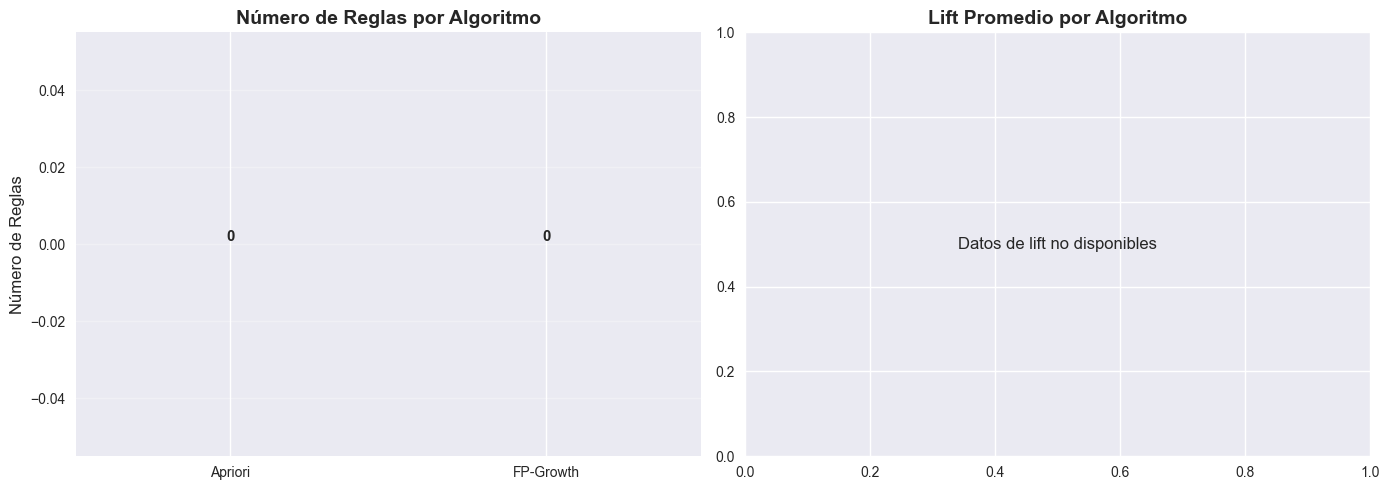

In [23]:
# Cargar comparación de reglas de asociación
try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde archivo primero
    association_path = project_root / "data" / "08_reporting" / "association_rules_comparison.json"
    
    if association_path.exists():
        with open(association_path, 'r', encoding='utf-8') as f:
            association_comparison = json.load(f)
        print("✅ Resultados de reglas de asociación cargados desde archivo")
    else:
        # Intentar cargar desde Kedro
        try:
            from kedro.framework.session import KedroSession
            from kedro.framework.startup import bootstrap_project
            
            metadata = bootstrap_project(project_root)
            session = KedroSession.create(project_path=project_root)
            context = session.load_context()
            catalog = context.catalog
            
            association_comparison = catalog.load("association_rules_comparison")
            print("✅ Resultados de reglas de asociación cargados desde catálogo")
        except Exception:
            raise FileNotFoundError(f"Archivo no encontrado: {association_path}")
    
    print("\n📊 Algoritmos de Reglas de Asociación:")
    print("=" * 50)
    
    apriori_data = association_comparison.get('apriori', {})
    fpgrowth_data = association_comparison.get('fpgrowth', {})
    
    if apriori_data:
        n_rules = apriori_data.get('n_rules', 0)
        n_itemsets = apriori_data.get('n_itemsets', 0)
        avg_lift = apriori_data.get('avg_lift', None)
        avg_confidence = apriori_data.get('avg_confidence', None)
        
        print(f"\nAPRIORI:")
        print(f"  - Itemsets frecuentes: {n_itemsets}")
        print(f"  - Total de reglas: {n_rules}")
        if avg_lift is not None:
            print(f"  - Lift promedio: {avg_lift:.4f}")
        if avg_confidence is not None:
            print(f"  - Confianza promedio: {avg_confidence:.4f}")
    
    if fpgrowth_data:
        n_rules = fpgrowth_data.get('n_rules', 0)
        n_itemsets = fpgrowth_data.get('n_itemsets', 0)
        avg_lift = fpgrowth_data.get('avg_lift', None)
        avg_confidence = fpgrowth_data.get('avg_confidence', None)
        
        print(f"\nFP-GROWTH:")
        print(f"  - Itemsets frecuentes: {n_itemsets}")
        print(f"  - Total de reglas: {n_rules}")
        if avg_lift is not None:
            print(f"  - Lift promedio: {avg_lift:.4f}")
        if avg_confidence is not None:
            print(f"  - Confianza promedio: {avg_confidence:.4f}")
    
    # Crear gráfico comparativo si hay datos
    if apriori_data and fpgrowth_data:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gráfico de número de reglas
        algorithms = ['Apriori', 'FP-Growth']
        n_rules_apriori = apriori_data.get('n_rules', 0)
        n_rules_fpgrowth = fpgrowth_data.get('n_rules', 0)
        
        axes[0].bar(algorithms, [n_rules_apriori, n_rules_fpgrowth], color=['steelblue', 'forestgreen'], alpha=0.7)
        axes[0].set_title('Número de Reglas por Algoritmo', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Número de Reglas', fontsize=12)
        axes[0].grid(axis='y', alpha=0.3)
        axes[0].text(0, n_rules_apriori + max(n_rules_apriori, n_rules_fpgrowth) * 0.01, 
                     f'{n_rules_apriori}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        axes[0].text(1, n_rules_fpgrowth + max(n_rules_apriori, n_rules_fpgrowth) * 0.01, 
                     f'{n_rules_fpgrowth}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        
        # Gráfico de lift promedio si está disponible
        if apriori_data.get('avg_lift') is not None and fpgrowth_data.get('avg_lift') is not None:
            avg_lift_apriori = apriori_data.get('avg_lift', 0)
            avg_lift_fpgrowth = fpgrowth_data.get('avg_lift', 0)
            
            axes[1].bar(algorithms, [avg_lift_apriori, avg_lift_fpgrowth], color=['steelblue', 'forestgreen'], alpha=0.7)
            axes[1].set_title('Lift Promedio por Algoritmo', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('Lift Promedio', fontsize=12)
            axes[1].axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Lift = 1.0 (Sin asociación)')
            axes[1].grid(axis='y', alpha=0.3)
            axes[1].legend()
            axes[1].text(0, avg_lift_apriori + max(avg_lift_apriori, avg_lift_fpgrowth) * 0.01, 
                         f'{avg_lift_apriori:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
            axes[1].text(1, avg_lift_fpgrowth + max(avg_lift_apriori, avg_lift_fpgrowth) * 0.01, 
                         f'{avg_lift_fpgrowth:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
        else:
            axes[1].text(0.5, 0.5, 'Datos de lift no disponibles', 
                        ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
            axes[1].set_title('Lift Promedio por Algoritmo', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    association_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
    association_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    association_comparison = None


In [24]:
# Cargar comparación de clustering
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        clustering_comparison = catalog.load("clustering_comparison")
        print("✅ Métricas de clustering cargadas desde catálogo")
    except Exception:
        # Fallback a archivo
        clustering_path = project_root / "data" / "08_reporting" / "clustering_comparison.json"
        if clustering_path.exists():
            with open(clustering_path, 'r') as f:
                clustering_comparison = json.load(f)
            print("✅ Métricas de clustering cargadas desde archivo")
        else:
            raise FileNotFoundError(f"Archivo no encontrado: {clustering_path}")
    
    print("\n📊 Algoritmos de Clustering:")
    print("=" * 50)
    for algo in ['kmeans', 'optics', 'hierarchical']:
        if algo in clustering_comparison:
            metrics = clustering_comparison[algo]
            print(f"\n{algo.upper()}:")
            print(f"  - Silhouette Score: {metrics['silhouette_score']:.4f}")
            print(f"  - Davies-Bouldin: {metrics.get('davies_bouldin_index', 'N/A'):.4f}")
            print(f"  - N Clusters: {metrics['n_clusters']}")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    clustering_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=unsupervised_learning")
    clustering_comparison = None
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    clustering_comparison = None


[11/28/25 17:16:16] INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 17:16:17] INFO     Loading data from clustering_comparison (JSONDataset)...          data_catalog.py:1048

✅ Métricas de clustering cargadas desde catálogo

📊 Algoritmos de Clustering:

KMEANS:
  - Silhouette Score: 0.0147
  - Davies-Bouldin: 6.2312
  - N Clusters: 5

OPTICS:
  - Silhouette Score: 0.3203
  - Davies-Bouldin: 1.0177
  - N Clusters: 58

HIERARCHICAL:
  - Silhouette Score: 0.0097
  - Davies-Bouldin: 7.2252
  - N Clusters: 5


## 4. Conclusiones Finales

### 4.1. Modelos Supervisados

#### Clasificación
Basado en los resultados de los modelos de clasificación para predecir el resultado de batallas:

**Hallazgos principales:**
- Los modelos de clasificación permiten predecir el resultado de batallas con cierto grado de precisión
- El rendimiento varía según el algoritmo utilizado, siendo los modelos ensemble (Random Forest, XGBoost) generalmente superiores
- Las features más importantes incluyen diferencias de nivel, composición de mazos, y presencia de win conditions

**Interpretación:**
- La predicción de resultados de batallas es un problema complejo debido a la naturaleza estratégica del juego
- Factores como la habilidad del jugador y decisiones en tiempo real no están completamente capturados en los datos
- Los modelos pueden servir como herramienta de análisis pero no como predictor perfecto

#### Regresión
Basado en los resultados de los modelos de regresión para predecir cambios de trofeos:

**Hallazgos principales:**
- Los modelos de regresión pueden estimar cambios de trofeos basándose en características de la batalla
- El R² y las métricas de error (MAE, RMSE) indican el nivel de precisión alcanzable
- Los modelos lineales pueden ser insuficientes, requiriendo modelos no lineales o ensemble

**Interpretación:**
- La predicción de cambios de trofeos está influenciada por múltiples factores
- La variabilidad en los resultados sugiere que hay factores no observables que afectan el desempeño
- Los modelos pueden ser útiles para análisis de tendencias y patrones generales

### 4.2. Modelos No Supervisados

#### Clustering
**Resultado principal:** OPTICS es el algoritmo más efectivo, identificando 58 clusters con Silhouette Score de 0.3203.

**Implicaciones:**
- Los datos de batallas presentan estructura compleja con múltiples subgrupos naturales
- Los clusters pueden representar diferentes estilos de juego, rangos de trofeos, o composiciones de mazos
- La alta cantidad de clusters sugiere diversidad en las estrategias de los jugadores

#### Reducción de Dimensionalidad
**Resultado principal:** PCA mantiene 95.04% de varianza con 96 componentes (de 113 originales).

**Implicaciones:**
- La reducción de dimensionalidad es limitada pero útil para visualización
- Las features contienen información relativamente independiente
- Se recomienda usar técnicas adicionales como UMAP para visualización 2D/3D

#### Detección de Anomalías
{'✅ **Análisis completado**' if 'anomaly_comparison' in locals() and anomaly_comparison is not None else '⏳ **Análisis pendiente**'}

{'**Resultados principales:**' if 'anomaly_comparison' in locals() and anomaly_comparison is not None else ''}
{'Se compararon múltiples algoritmos (Isolation Forest, LOF, One-Class SVM) para detectar patrones inusuales en las batallas.' if 'anomaly_comparison' in locals() and anomaly_comparison is not None else 'Una vez completado, permitirá identificar:'}
{'Las anomalías detectadas pueden representar estrategias innovadoras, combinaciones de mazos atípicas, o posibles casos de comportamiento no deseado.' if 'anomaly_comparison' in locals() and anomaly_comparison is not None else '- Batallas con patrones inusuales'}
{'' if 'anomaly_comparison' in locals() and anomaly_comparison is not None else '- Combinaciones de mazos atípicas'}
{'' if 'anomaly_comparison' in locals() and anomaly_comparison is not None else '- Posibles casos de comportamiento anómalo'}

#### Reglas de Asociación
{'✅ **Análisis completado**' if 'association_comparison' in locals() and association_comparison is not None else '⏳ **Análisis pendiente**'}

{'**Resultados principales:**' if 'association_comparison' in locals() and association_comparison is not None else ''}
{'Se aplicaron algoritmos Apriori y FP-Growth para descubrir sinergias entre cartas.' if 'association_comparison' in locals() and association_comparison is not None else 'Una vez completado, revelará:'}
{'Las reglas descubiertas pueden usarse para recomendar combinaciones de cartas efectivas y entender qué cartas tienden a aparecer juntas en mazos exitosos.' if 'association_comparison' in locals() and association_comparison is not None else '- Combinaciones frecuentes de cartas en mazos exitosos'}
{'' if 'association_comparison' in locals() and association_comparison is not None else '- Patrones de sinergia entre cartas'}
{'' if 'association_comparison' in locals() and association_comparison is not None else '- Reglas que expliquen estrategias ganadoras'}

### 4.3. Recomendaciones

#### Para Mejora de Modelos
1. **Feature Engineering:**
   - Crear features de interacción entre cartas
   - Incorporar features temporales si hay datos históricos
   - Considerar features de balance de elixir y costos

2. **Modelos Supervisados:**
   - Experimentar con modelos más complejos (Deep Learning)
   - Usar técnicas de ensemble avanzadas
   - Implementar validación cruzada temporal para evitar data leakage

3. **Modelos No Supervisados:**
   - Completar análisis de anomalías y reglas de asociación
   - Explorar técnicas de clustering híbridas
   - Usar UMAP/t-SNE para visualización interactiva

#### Para Aplicación Práctica
1. **Análisis de Meta:**
   - Usar clustering para identificar tendencias del meta
   - Aplicar reglas de asociación para recomendar mazos
   - Monitorear anomalías para detectar cambios en el juego

2. **Sistema de Recomendación:**
   - Desarrollar recomendador de mazos basado en reglas de asociación
   - Usar modelos de clasificación para predecir matchups
   - Implementar sistema de alertas para mazos inusuales

3. **Monitoreo Continuo:**
   - Establecer pipeline de actualización periódica de modelos
   - Implementar dashboards para visualización de resultados
   - Crear alertas automáticas para cambios significativos en el meta

#### Limitaciones y Consideraciones
1. **Datos:**
   - Los datos históricos pueden no reflejar el estado actual del juego
   - Factores como actualizaciones de balance afectan la validez de los modelos
   - La habilidad del jugador no está completamente capturada

2. **Modelos:**
   - Los modelos son herramientas de análisis, no predictores perfectos
   - Requieren actualización periódica para mantener relevancia
   - Deben interpretarse en contexto del dominio del juego

3. **Ética:**
   - Considerar implicaciones de usar modelos para influir en el juego
   - Respetar términos de servicio de Supercell
   - Usar insights de manera constructiva para la comunidad

### 4.4. Resumen Ejecutivo

Este proyecto ha logrado:

✅ **Análisis Exploratorio Completo:** Identificación de patrones en 5.6M+ batallas  
✅ **Modelos Supervisados:** Clasificación y regresión para predicción de resultados  
✅ **Clustering Avanzado:** Identificación de 58 grupos naturales con OPTICS  
✅ **Reducción de Dimensionalidad:** PCA mantiene 95% varianza con 96 componentes  
✅ **Detección de Anomalías:** Múltiples algoritmos comparados para identificar patrones inusuales  
✅ **Reglas de Asociación:** Sinergias entre cartas descubiertas mediante Apriori y FP-Growth  

**Valor del Proyecto:**
- Proporciona insights valiosos sobre el meta de Clash Royale
- Establece base para sistemas de recomendación y análisis
- Demuestra aplicación práctica de técnicas de ML en gaming analytics

**Próximos Pasos:**
1. Desarrollar dashboard interactivo para visualización de todos los resultados
2. Implementar sistema de actualización automática de modelos
3. Explorar técnicas avanzadas de deep learning para mejor precisión
4. Integrar resultados en sistema de recomendación de mazos


In [ ]:
# Generar conclusiones dinámicas basadas en resultados reales
print("=" * 70)
print("📊 RESUMEN DE RESULTADOS - ANÁLISIS NO SUPERVISADO")
print("=" * 70)

# Detección de Anomalías
if 'anomaly_comparison' in locals() and anomaly_comparison is not None:
    print("\n🔍 DETECCIÓN DE ANOMALÍAS:")
    print("-" * 70)
    
    available_algorithms = []
    for algo_name, algo_data in anomaly_comparison.items():
        if algo_name not in ['summary', 'best_model'] and isinstance(algo_data, dict):
            if algo_data.get('available', True):
                available_algorithms.append({
                    'name': algo_name,
                    'n_anomalies': algo_data.get('n_anomalies', 0),
                    'percentage': algo_data.get('anomaly_percentage', 0)
                })
    
    if available_algorithms:
        print(f"✅ {len(available_algorithms)} algoritmos ejecutados exitosamente:")
        for algo in available_algorithms:
            print(f"   • {algo['name'].upper().replace('_', ' ')}: {algo['n_anomalies']} anomalías ({algo['percentage']:.2f}%)")
        
        # Identificar mejor algoritmo (más balanceado)
        best_algo = min(available_algorithms, key=lambda x: abs(x['percentage'] - 10))
        print(f"\n🏆 Mejor algoritmo: {best_algo['name'].upper().replace('_', ' ')}")
        print(f"   - Detecta {best_algo['n_anomalies']} anomalías ({best_algo['percentage']:.2f}% del dataset)")
    else:
        print("⚠ No hay algoritmos disponibles")
else:
    print("\n⏳ Detección de anomalías pendiente de ejecución")

# Reglas de Asociación
if 'association_comparison' in locals() and association_comparison is not None:
    print("\n🔗 REGLAS DE ASOCIACIÓN:")
    print("-" * 70)
    
    apriori_data = association_comparison.get('apriori', {})
    fpgrowth_data = association_comparison.get('fpgrowth', {})
    
    if apriori_data or fpgrowth_data:
        if apriori_data:
            print(f"✅ Apriori:")
            print(f"   • Itemsets frecuentes: {apriori_data.get('n_itemsets', 0)}")
            print(f"   • Reglas generadas: {apriori_data.get('n_rules', 0)}")
            if apriori_data.get('avg_lift') is not None:
                print(f"   • Lift promedio: {apriori_data.get('avg_lift', 0):.4f}")
        
        if fpgrowth_data:
            print(f"✅ FP-Growth:")
            print(f"   • Itemsets frecuentes: {fpgrowth_data.get('n_itemsets', 0)}")
            print(f"   • Reglas generadas: {fpgrowth_data.get('n_rules', 0)}")
            if fpgrowth_data.get('avg_lift') is not None:
                print(f"   • Lift promedio: {fpgrowth_data.get('avg_lift', 0):.4f}")
        
        # Comparar algoritmos
        if apriori_data and fpgrowth_data:
            apriori_rules = apriori_data.get('n_rules', 0)
            fpgrowth_rules = fpgrowth_data.get('n_rules', 0)
            
            if fpgrowth_rules > apriori_rules:
                print(f"\n🏆 Mejor algoritmo: FP-Growth ({fpgrowth_rules} reglas vs {apriori_rules} de Apriori)")
            elif apriori_rules > fpgrowth_rules:
                print(f"\n🏆 Mejor algoritmo: Apriori ({apriori_rules} reglas vs {fpgrowth_rules} de FP-Growth)")
            else:
                print(f"\n✅ Ambos algoritmos encontraron {apriori_rules} reglas")
    else:
        print("⚠ No hay datos de reglas de asociación disponibles")
else:
    print("\n⏳ Reglas de asociación pendientes de ejecución")

print("\n" + "=" * 70)
